# PART 1: Component level eval set
Our component eval scripts will be used for this.

### Notes:
1. CVAT labels start from 1, while our code expects label ids to start from 0. So, labels should be updated in advance.
2. Order lines of 2-col pages. This should be handled in the same way in the pipeline.


**Note:** CVAT data should be exported in both "coco 1.0" and "cvat for images 1.1" formats.

## 1. Line and layout

1. Export data from CVAT in "coco 1.0" format
2. Annotation file should be splitted into 2 annotation files (line and layout) for component level evaluation
3. Ids should be updated to start from 0 insted of 1 (cvat default)

In [3]:
import json

input_json = "/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/instances_default.json"
output_textline = "/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/textline_gt.json"
output_layout = "/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/layout_gt.json"

#  Load 
with open(input_json, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

#  Identify category IDs for split 
textline_cat_ids = {cat["id"] for cat in categories if cat["name"] == "textline"}
other_cat_ids = {cat["id"] for cat in categories if cat["name"] != "textline"}

#  Split annotations 
textline_anns = [ann.copy() for ann in annotations if ann["category_id"] in textline_cat_ids]
other_anns = [ann.copy() for ann in annotations if ann["category_id"] in other_cat_ids]

#  Create category subsets 
textline_categories = [cat.copy() for cat in categories if cat["id"] in textline_cat_ids]
other_categories = [cat.copy() for cat in categories if cat["id"] in other_cat_ids]

#  Reindex helper 
def reindex(cats, anns):
    old2new = {}
    new_cats = []
    for new_id, cat in enumerate(cats):
        old2new[cat["id"]] = new_id
        new_cats.append({
            "id": new_id,
            "name": cat["name"],
            "supercategory": cat.get("supercategory", "")
        })
    for ann in anns:
        ann["category_id"] = old2new[ann["category_id"]]
    return new_cats, anns

#  Reindex categories + annotations 
textline_categories, textline_anns = reindex(textline_categories, textline_anns)
other_categories, other_anns = reindex(other_categories, other_anns)

#  Build final COCO JSONs 
coco_textline = {
    "images": images,            
    "annotations": textline_anns,
    "categories": textline_categories
}

coco_other = {
    "images": images,           
    "annotations": other_anns,
    "categories": other_categories
}

#  Save 
with open(output_textline, "w", encoding="utf-8") as f:
    json.dump(coco_textline, f, indent=2, ensure_ascii=False)

with open(output_layout, "w", encoding="utf-8") as f:
    json.dump(coco_other, f, indent=2, ensure_ascii=False)

print(" Split complete:")
print(f" {output_textline}")
print(f" {output_layout}")



 Split complete:
 /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/textline_gt.json
 /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/layout_gt.json


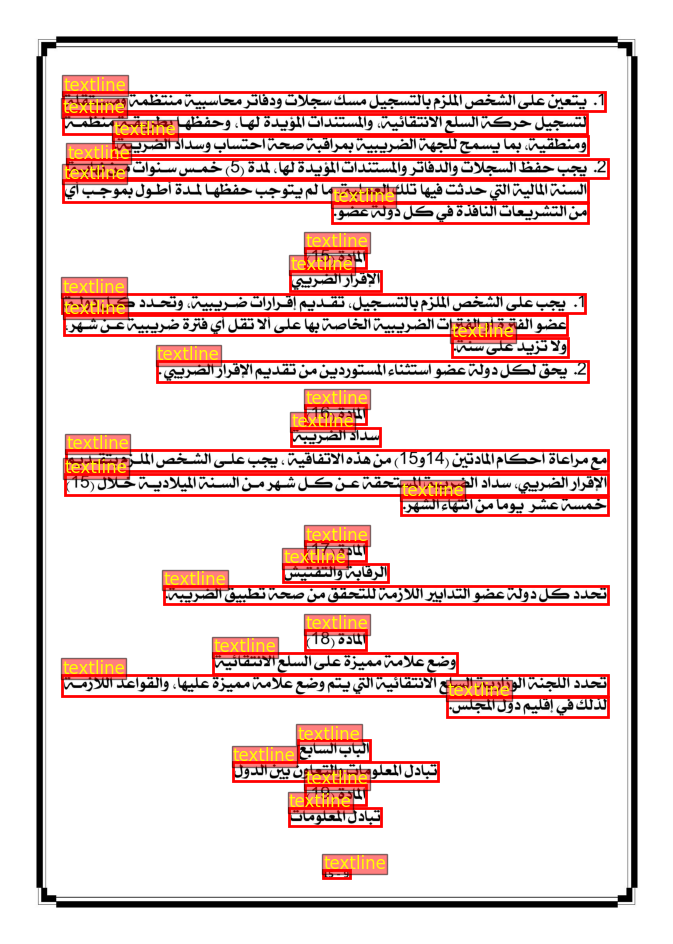

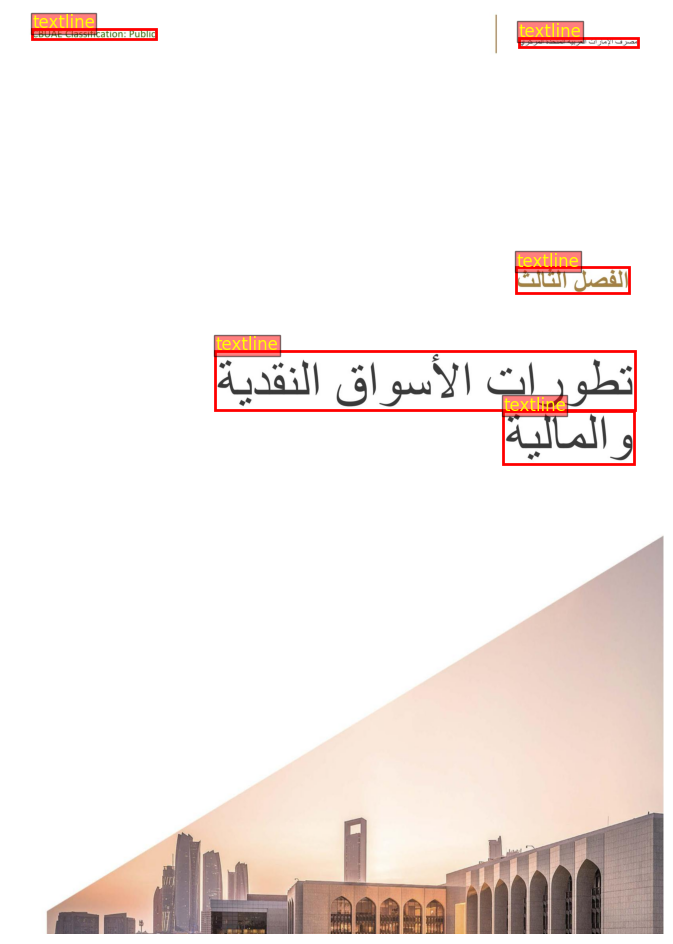

In [6]:
# visualize the data to verify the saved coco.json
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


COCO_JSON = "/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/textline_gt.json"   
IM_DIR = "/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/images"
MAX_IMAGES = 2     

# LOAD COCO
with open(COCO_JSON, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = {img["id"]: img for img in coco["images"]}
annotations_by_image = {}
for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# VISUALIZE INLINE
for i, (img_id, img_info) in enumerate(images.items()):
    if i >= MAX_IMAGES:
        break

    img_path = os.path.join(IM_DIR, img_info["file_name"])
    if not os.path.exists(img_path):
        print("Missing:", img_path)
        continue

    image = Image.open(img_path)
    fig, ax = plt.subplots(1, figsize=(12,12))
    ax.imshow(image)

    # draw boxes
    for ann in annotations_by_image.get(img_id, []):
        x, y, w, h = ann["bbox"]
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        cat_name = categories[ann["category_id"]]
        ax.text(
            x, y-2, cat_name,
            fontsize=12, color='yellow',
            bbox=dict(facecolor='red', alpha=0.5, pad=1)
        )

    ax.axis("off")
    plt.show()

## 2. Text
1. Export data in "cvat for images 1.1" format
2. Save the data in this format image_name.png企gt_text企parent_folder企full_image_name

In [ ]:
import os
import xml.etree.ElementTree as ET
from PIL import Image
import uuid
from arabic_cleaning.cleaning_utils import cleanse_document, normalize_similar_chars, remove_diacritics_tatweel


def clean_text(text):
    text = text.replace('\n', ' ').replace('\r', ' ').strip()
    text= cleanse_document(text, cleansers=[normalize_similar_chars])
    text= cleanse_document(text, cleansers=[remove_diacritics_tatweel])
    return text

def is_inside(inner, outer):
    return (
        inner[0] >= outer[0] and
        inner[1] >= outer[1] and
        inner[2] <= outer[2] and
        inner[3] <= outer[3]
    )

def create_ocr_eval_data(
    parent_folder,
    xml_path,
    images_dir,
    output_dir,
    output_txt,
    skipped_lines,
    skip_picture_textlines=False
):
   
    sep = '企'
    os.makedirs(output_dir, exist_ok=True)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    lines = []
    skipped_items = []
    for image_tag in root.findall('image'):
        image_name = image_tag.get('name')
        image_path = os.path.join(images_dir, image_name)
        
        try:
            img = Image.open(image_path)
        except FileNotFoundError:
            print(f"Image not found: {image_path}")
            continue

        # Collect Picture boxes ONLY if skip_picture_textlines is True
        picture_boxes = []
        if skip_picture_textlines:
            for box in image_tag.findall('box'):
                if box.get('label') == 'Picture':
                    picture_boxes.append((
                        float(box.get('xtl')),
                        float(box.get('ytl')),
                        float(box.get('xbr')),
                        float(box.get('ybr'))
                    ))

        for box in image_tag.findall('box'):
            if box.get('label') != 'textline':
                continue
            
            xtl = float(box.get('xtl'))
            ytl = float(box.get('ytl'))
            xbr = float(box.get('xbr'))
            ybr = float(box.get('ybr'))

            textline_box = (xtl, ytl, xbr, ybr)

            # skip textlines that are inside picture boxes
            if skip_picture_textlines:
                if any(is_inside(textline_box, pic_box) for pic_box in picture_boxes):
                    continue

            ocr_text = ''
            for attr in box.findall('attribute'):
                if attr.get('name') == 'ocr_text':
                    ocr_text = attr.text
                    break

            if not ocr_text:
                skipped_items.append(
                    f"{image_path}.png{sep}{ocr_text}{sep}{parent_folder}{sep}{image_name}"
                )
                continue # skip boxes with empty ocr_text

            # crop and save lineees
            cropped = img.crop((xtl, ytl, xbr, ybr))

            #####
            unique_id = uuid.uuid4().hex
            cropped_filename = f"{unique_id}.png"
            cropped_path = os.path.join(output_dir, cropped_filename)
            cropped.save(cropped_path)

            
            ## ignore lines with "X_X_X_X_X" in text (we don't handle dots (X_X_X_X_X) appear in forms for now), could change later
            cleaned_text = clean_text(ocr_text)
            if "X_X_X_X_X" not in cleaned_text:
                line = f"{cropped_filename}{sep}{cleaned_text}{sep}{parent_folder}{sep}{image_name}"
                lines.append(line)


    print(len(lines))
    with open(output_txt, 'a', encoding='utf-8') as f:
        for line in lines:
            f.write(line + '\n')
    with open(skipped_lines, 'a', encoding='utf-8') as f_skipped:
        for items in skipped_items:
            f_skipped.write(items + '\n')


    print(f"Saved {len(lines)} cropped images and their  text to {output_txt}")
    

In [ ]:
parent_folder = '/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1' #where cvat exported data is
images_dir = '/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/images'


output_images = '/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/lines_images_without_pictures' # where cropped line images will be saved
output_txt = '/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/images_with_text_without_pictures.txt'
skipped_lines = '/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/skipped_lines_without_pictures.txt' # only for validation 
 


xml_path = os.path.join(parent_folder, 'annotations.xml')
print(f"Processing {parent_folder}...")
create_ocr_eval_data(parent_folder, xml_path, images_dir, output_images, output_txt,skipped_lines, skip_picture_textlines=True)



Processing /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1...
Saved 27566 cropped images and their text to /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/temp.txt


# PART2: End2end data prep.

## Collect lines from each page/image to create ground-truth text
1. Export data in "CVAT for images 1.1" format.
2. Sort the layout bounding boxes (bboxes).
3. Gather the lines corresponding to each layout object and sort them.
4. Save the sorted lines of each image into a file named `image_name.txt`, which will be used for evaluation later.


In [1]:
import xml.etree.ElementTree as ET
import os

# Path to CVAT XML
xml_file = "/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/annotations_v3.xml"
output_dir = "/ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/gt_texts_v3"

os.makedirs(output_dir, exist_ok=True)  

def bbox_inside(inner, outer):
    """Check if inner box is fully inside outer box"""
    ix1, iy1, ix2, iy2 = inner
    ox1, oy1, ox2, oy2 = outer
    return ix1 >= ox1 and iy1 >= oy1 and ix2 <= ox2 and iy2 <= oy2

# Parse XML
tree = ET.parse(xml_file)
root = tree.getroot()

IGNORE_LABELS = {"Table", "Picture"}  # labels to ignore

for image in root.findall("image"):
    image_name = image.attrib["name"]
    image_id = image.attrib["id"]

    # Collect all boxes for this image
    boxes = []
    for box in image.findall("box"):
        label = box.attrib['label']
        
         # Skip ignored labels
        if label in IGNORE_LABELS:
            continue

        bbox = (
            float(box.attrib['xtl']),
            float(box.attrib['ytl']),
            float(box.attrib['xbr']),
            float(box.attrib['ybr'])
        )
        text_elem = box.find("attribute[@name='ocr_text']")
        text = text_elem.text.strip() if text_elem is not None and text_elem.text else ""
        boxes.append({'label': label, 'bbox': bbox, 'text': text})

    # Separate elements and textlines
    elements = [b for b in boxes if b['label'] not in ['textline']]
    textlines = [b for b in boxes if b['label'] == 'textline']

    # Sort layout elements top-to-bottom, right-to-left
    elements_sorted = sorted(elements, key=lambda e: (e['bbox'][1], -e['bbox'][0]))

    # Collect lines sequentially
    all_lines_ordered = []

    for elem in elements_sorted:
        elem_bbox = elem['bbox']
        # Lines inside this element
        lines_in_elem = [l for l in textlines if bbox_inside(l['bbox'], elem_bbox)]
        # Sort lines top-to-bottom, right-to-left
        lines_in_elem.sort(key=lambda l: (l['bbox'][1], -l['bbox'][0]))
        # Add textlines sequentially
        all_lines_ordered.extend([l['text'] for l in lines_in_elem])


    # Save to text file (one per image)
    base_name = os.path.splitext(image_name)[0]
    output_file = os.path.join(output_dir, f"{base_name}.txt")
    with open(output_file, "w", encoding="utf-8") as f:
        for line in all_lines_ordered:
            f.write(line + "\n")

    print(f"Saved {len(all_lines_ordered)} lines to {output_file}")


Saved 29 lines to /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/gt_texts_v3/00061f593d2e41dda7a7ef8c54d1994b.txt
Saved 5 lines to /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/gt_texts_v3/008cf275bca34791be44335bca5615d8.txt
Saved 29 lines to /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/gt_texts_v3/00b1e73a0dd64f87b5136e490b9e929a.txt
Saved 25 lines to /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/gt_texts_v3/00e949ca229e4bbaa585090dcd66f0cf.txt
Saved 0 lines to /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e2e_eval_data/task_248_dataset_2026_01_26_09_55_18_cvat for images 1.1/gt_texts_v3/00f19e984c2d4686804062a93422e09e.txt
Saved 3 lines to /ephemeral/home/data/TalkToDocs-Ingest/data/mozn_e